In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load spreadsheet
# -----------------------------
#Load Spreadsheet of Housing Prices
file_path = "House Sales by County.xlsx"

data = pd.read_excel(file_path, sheet_name=None)

print("Available counties:")
print(list(data.keys()))

Available counties:
['BATH AND NORTH EAST SOMERSET', 'BEDFORD', 'BLACKBURN WITH DARWEN', 'BLACKPOOL', 'BLAENAU GWENT', 'BOURNEMOUTH, CHRISTCHURCH AND P', 'BRACKNELL FOREST', 'BRIDGEND', 'BRIGHTON AND HOVE', 'BUCKINGHAMSHIRE', 'CAERPHILLY', 'CAMBRIDGESHIRE', 'CARDIFF', 'CARMARTHENSHIRE', 'CENTRAL BEDFORDSHIRE', 'CEREDIGION', 'CHESHIRE EAST', 'CHESHIRE WEST AND CHESTER', 'CITY OF BRISTOL', 'CITY OF DERBY', 'CITY OF KINGSTON UPON HULL', 'CITY OF NOTTINGHAM', 'CITY OF PETERBOROUGH', 'CITY OF PLYMOUTH', 'CONWY', 'CORNWALL', 'COUNTY DURHAM', 'CUMBERLAND', 'DARLINGTON', 'DENBIGHSHIRE', 'DERBYSHIRE', 'DEVON', 'DORSET', 'EAST RIDING OF YORKSHIRE', 'EAST SUSSEX', 'ESSEX', 'FLINTSHIRE', 'GLOUCESTERSHIRE', 'GREATER LONDON', 'GREATER MANCHESTER', 'GWYNEDD', 'HALTON', 'HAMPSHIRE', 'HARTLEPOOL', 'HEREFORDSHIRE', 'HERTFORDSHIRE', 'ISLE OF ANGLESEY', 'ISLE OF WIGHT', 'KENT', 'LANCASHIRE', 'LEICESTER', 'LEICESTERSHIRE', 'LINCOLNSHIRE', 'LUTON', 'MEDWAY', 'MERSEYSIDE', 'MERTHYR TYDFIL', 'MIDDLESBROUGH', 

In [2]:
# -----------------------------
# 2. User inputs
# -----------------------------
county = "WEST SUSSEX"      # change this
asking_price = 450000       # change this
income = 90000              # annual household income
deposit = 80000             # deposit amount
rate = 5.2                  # mortgage rate in %
years = 30                  # mortgage term



County housing summary
----------------------
County: WEST SUSSEX
Number of sales: 1720
Average price: 493535
Median price: 375000
Typical price range: 275000 - 530500

Price comparison
----------------
Asking price: 450000
Price is typical for the county

Financing structure
-------------------
Loan-to-value: 0.82
Moderate leverage

Mortgage analysis
-----------------
Loan amount: 370000
Monthly payment: 2032
Payment / income ratio: 0.27
Comfortable affordability

Buyer score
-----------
85 / 100
Rating: Strong

Yearly county average prices
----------------------------
year
2021    299033.0
2022    472936.5
2023    404997.5
2024    327500.0
2025    375000.0
2026    400000.0
Name: price, dtype: float64

Market trend
------------
Growth over sample: 33.76 %
Market direction: strong growth

Warnings
--------
No major warnings

Final decision
--------------
Looks reasonable at this basic county-level view

Summary
--------
- Price vs market: typical
- Affordability: comfortable
- Buyer s

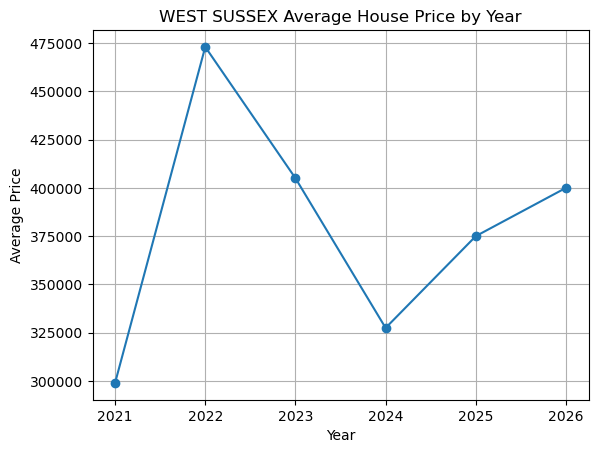

In [8]:
# -----------------------------
# 3. Load county data
# -----------------------------
df = data[county].copy()
df["date"] = pd.to_datetime(df["date"])

# -----------------------------
# 4. County market statistics
# -----------------------------
avg_price = df["price"].mean()
median_price = df["price"].median()
lower_range = df["price"].quantile(0.25)
upper_range = df["price"].quantile(0.75)
sales_count = len(df)

print("\nCounty housing summary")
print("----------------------")
print("County:", county)
print("Number of sales:", sales_count)
print("Average price:", round(avg_price))
print("Median price:", round(median_price))
print("Typical price range:", round(lower_range), "-", round(upper_range))

# -----------------------------
# 5. Asking price comparison
# -----------------------------
print("\nPrice comparison")
print("----------------")
print("Asking price:", asking_price)

if asking_price > upper_range:
    price_status = "overpriced"
    print("Property may be overpriced for the county")
elif asking_price < lower_range:
    price_status = "cheap"
    print("Property may be relatively cheap for the county")
else:
    price_status = "typical"
    print("Price is typical for the county")

# Deposit as % of price
ltv = loan / asking_price

print("\nFinancing structure")
print("-------------------")
print("Loan-to-value:", round(ltv, 2))

if ltv > 0.9:
    print("Very high leverage")
elif ltv > 0.75:
    print("Moderate leverage")
else:
    print("Low leverage")

# -----------------------------
# 6. Mortgage affordability
# -----------------------------
loan = asking_price - deposit
monthly_rate = rate / 100 / 12
months = years * 12

payment = loan * (monthly_rate * (1 + monthly_rate) ** months) / ((1 + monthly_rate) ** months - 1)
monthly_income = income / 12
ratio = payment / monthly_income

print("\nMortgage analysis")
print("-----------------")
print("Loan amount:", round(loan))
print("Monthly payment:", round(payment))
print("Payment / income ratio:", round(ratio, 2))

if ratio > 0.40:
    affordability_status = "high pressure"
    print("High financial pressure")
elif ratio > 0.30:
    affordability_status = "moderate pressure"
    print("Moderate financial pressure")
else:
    affordability_status = "comfortable"
    print("Comfortable affordability")


# 8. Buyer score
# -----------------------------
score = 100

if asking_price > upper_range:
    score -= 30
elif asking_price > median_price:
    score -= 15

if ratio > 0.40:
    score -= 40
elif ratio > 0.30:
    score -= 20

score = max(0, min(score, 100))

print("\nBuyer score")
print("-----------")
print(score, "/ 100")

if score >= 80:
    print("Rating: Strong")
elif score >= 60:
    print("Rating: Reasonable")
elif score >= 40:
    print("Rating: Caution")
else:
    print("Rating: Risky")

# -----------------------------
# 9. County price trend
# -----------------------------
df["year"] = df["date"].dt.year
yearly_prices = df.groupby("year")["price"].median()

print("\nYearly county average prices")
print("----------------------------")
print(yearly_prices)

first_price = yearly_prices.iloc[0]
last_price = yearly_prices.iloc[-1]
growth_rate = (last_price - first_price) / first_price

print("\nMarket trend")
print("------------")
print("Growth over sample:", round(growth_rate * 100, 2), "%")

if growth_rate > 0.10:
    print("Market direction: strong growth")
elif growth_rate > 0.03:
    print("Market direction: modest growth")
elif growth_rate > -0.03:
    print("Market direction: broadly flat")
else:
    print("Market direction: falling")

warnings = []

if asking_price > upper_range:
    warnings.append("Price above typical range")

if ratio > 0.40:
    warnings.append("High affordability pressure")

if growth_rate < 0:
    warnings.append("Market trend is falling")

print("\nWarnings")
print("--------")

if warnings:
    for w in warnings:
        print("-", w)
else:
    print("No major warnings")

# -----------------------------
# 7. Final decision
# -----------------------------
print("\nFinal decision")
print("--------------")
print(decision)

print("\nSummary")
print("--------")
print(f"- Price vs market: {price_status}")
print(f"- Affordability: {affordability_status}")
print(f"- Buyer score: {score}/100")
# -----------------------------

# -----------------------------
# 10. Plot trend
# -----------------------------
yearly_prices.plot(marker="o")
plt.title(f"{county} Average House Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()